# DNN on CIFAR10 Image Dataset

In [29]:
import tensorflow as tf
import keras
from matplotlib import pyplot as plt

In [30]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train_scaled = X_train/255.0
X_test_scaled = X_test/255.0

In [53]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (32, 32, 3)),
    keras.layers.Flatten()
]
)

for i in range(20):
    model.add(keras.layers.Dense(100, 'elu', kernel_initializer = 'he_normal'))

model.add(keras.layers.Dense(10, 'softmax', kernel_initializer='he_normal'))

model.compile(
    keras.optimizers.Nadam(learning_rate = 0.0001),
    keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)


In [54]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True)
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 100,
    callbacks = [early_stopping],
    validation_split = 0.2
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2578 - loss: 2.0553 - val_accuracy: 0.3611 - val_loss: 1.7727
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3783 - loss: 1.7186 - val_accuracy: 0.3792 - val_loss: 1.7138
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4152 - loss: 1.6314 - val_accuracy: 0.3936 - val_loss: 1.6947
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4352 - loss: 1.5697 - val_accuracy: 0.4205 - val_loss: 1.6259
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4543 - loss: 1.5252 - val_accuracy: 0.4373 - val_loss: 1.5847
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4682 - loss: 1.4869 - val_accuracy: 0.4564 - val_loss: 1.5314
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4791 - loss: 1.4552 - val_accuracy: 0.4447 - val_loss: 1.5509
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4867 - loss: 1

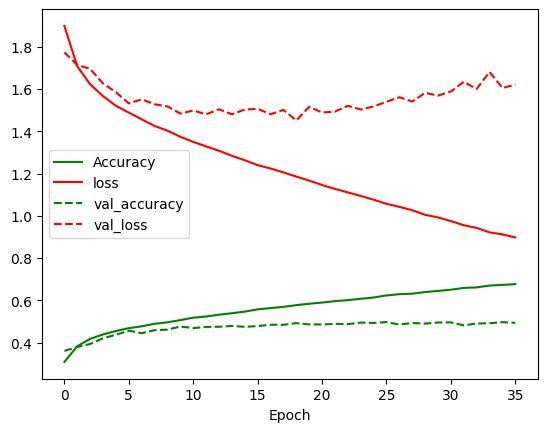

In [55]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.plot(accuracy, 'g-', label = 'Accuracy')
plt.plot(loss, 'r-', label = 'loss')
plt.plot(val_accuracy, 'g--', label = 'val_accuracy')
plt.plot(val_loss, 'r--', label = 'val_loss')
plt.xlabel('Epoch')
plt.legend(loc = 'best')
plt.show()

The model overfits the data!

## Using Batch Normalization

In [58]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (32, 32, 3)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization()
])

for i in range(20):
    model.add(keras.layers.Dense(100, 'elu', kernel_initializer = 'he_normal'))
    model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Dense(10, 'softmax', kernel_initializer='he_normal'))

model.compile(
    keras.optimizers.Nadam(learning_rate = 0.0001),
    keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

In [59]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True)
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 100,
    callbacks = [early_stopping],
    validation_split = 0.2
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.1865 - loss: 2.4152 - val_accuracy: 0.3222 - val_loss: 1.8883
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3173 - loss: 1.8892 - val_accuracy: 0.3732 - val_loss: 1.7448
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3595 - loss: 1.7756 - val_accuracy: 0.4057 - val_loss: 1.6635
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.3891 - loss: 1.7089 - val_accuracy: 0.4217 - val_loss: 1.6319
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4061 - loss: 1.6541 - val_accuracy: 0.4381 - val_loss: 1.5687
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4231 - loss: 1.6133 - val_accuracy: 0.4536 - val_loss: 1.5339
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4408 - loss: 1.5703 - val_accuracy: 0.4573 - val_loss: 1.5265
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.4468 - loss: 

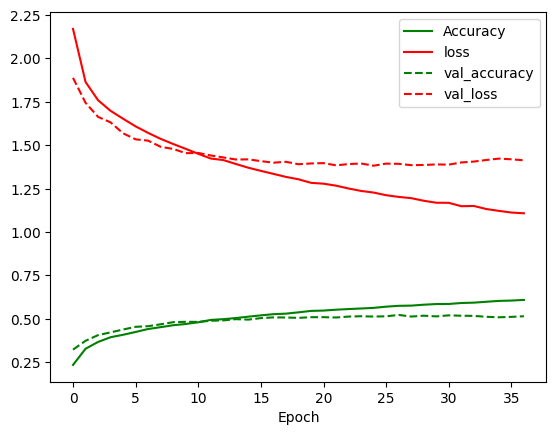

In [60]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.plot(accuracy, 'g-', label = 'Accuracy')
plt.plot(loss, 'r-', label = 'loss')
plt.plot(val_accuracy, 'g--', label = 'val_accuracy')
plt.plot(val_loss, 'r--', label = 'val_loss')
plt.xlabel('Epoch')
plt.legend(loc = 'best')
plt.show()

The model overfits less!

## Self-Normalization

In [61]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (32, 32, 3)),
    keras.layers.Flatten(),
])

for i in range(20):
    model.add(keras.layers.Dense(100, 'selu', kernel_initializer = 'lecun_normal'))

model.add(keras.layers.Dense(10, 'softmax', kernel_initializer='lecun_normal'))

model.compile(
    keras.optimizers.Nadam(learning_rate = 0.0001),
    keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

In [62]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_accuracy', patience = 10, restore_best_weights = True)
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 100,
    callbacks = [early_stopping],
    validation_split = 0.2
)

Epoch 1/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2728 - loss: 1.9716 - val_accuracy: 0.3677 - val_loss: 1.7474
Epoch 2/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3803 - loss: 1.7134 - val_accuracy: 0.4041 - val_loss: 1.6530
Epoch 3/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4164 - loss: 1.6149 - val_accuracy: 0.4016 - val_loss: 1.6475
Epoch 4/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4338 - loss: 1.5734 - val_accuracy: 0.4232 - val_loss: 1.6131
Epoch 5/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4551 - loss: 1.5213 - val_accuracy: 0.4506 - val_loss: 1.5579
Epoch 6/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4651 - loss: 1.4855 - val_accuracy: 0.4477 - val_loss: 1.5462
Epoch 7/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4780 - loss: 1.4547 - val_accuracy: 0.4596 - val_loss: 1.5146
Epoch 8/100
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4829 - loss: 1

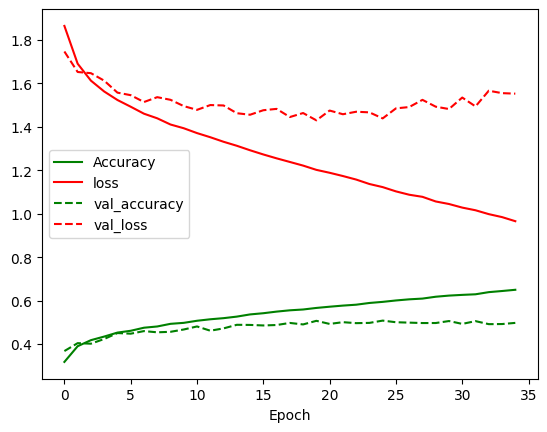

In [63]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.plot(accuracy, 'g-', label = 'Accuracy')
plt.plot(loss, 'r-', label = 'loss')
plt.plot(val_accuracy, 'g--', label = 'val_accuracy')
plt.plot(val_loss, 'r--', label = 'val_loss')
plt.xlabel('Epoch')
plt.legend(loc = 'best')
plt.show()

Slightly worse than the previous model.

## Alpha dropout and self-normalization

In [109]:
model = keras.models.Sequential([
    keras.layers.Input(shape = (32, 32, 3)),
    keras.layers.Flatten(),
    keras.layers.BatchNormalization(),
])

for i in range(20):
    model.add(keras.layers.Dense(100, 'selu', kernel_initializer = 'lecun_uniform'))
    keras.layers.BatchNormalization()

model.add(keras.layers.AlphaDropout(0.1))
model.add(keras.layers.Dense(10, 'softmax', kernel_initializer='lecun_uniform'))

model.compile(
    keras.optimizers.Nadam(learning_rate = 0.0005),
    keras.losses.SparseCategoricalCrossentropy(),
    metrics = ['accuracy']
)

In [101]:
early_stopping = keras.callbacks.EarlyStopping(monitor = 'val_accuracy', patience = 20, restore_best_weights = True)
history = model.fit(
    X_train_scaled,
    y_train,
    epochs = 150,
    callbacks = [early_stopping],
    validation_split = 0.2
)

Epoch 1/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.2563 - loss: 2.0721 - val_accuracy: 0.3483 - val_loss: 1.8255
Epoch 2/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3796 - loss: 1.7528 - val_accuracy: 0.3954 - val_loss: 1.6833
Epoch 3/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4196 - loss: 1.6456 - val_accuracy: 0.4375 - val_loss: 1.6197
Epoch 4/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4370 - loss: 1.6008 - val_accuracy: 0.4516 - val_loss: 1.5784
Epoch 5/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4607 - loss: 1.5317 - val_accuracy: 0.4548 - val_loss: 1.5630
Epoch 6/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4782 - loss: 1.4921 - val_accuracy: 0.4625 - val_loss: 1.5278
Epoch 7/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4972 - loss: 1.4511 - val_accuracy: 0.4661 - val_loss: 1.5391
Epoch 8/150
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5076 - loss: 1

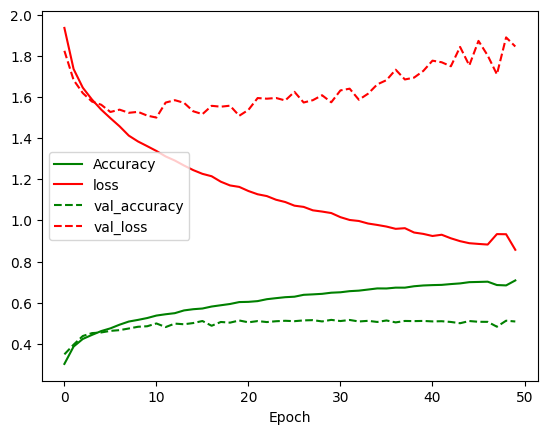

In [102]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.plot(accuracy, 'g-', label = 'Accuracy')
plt.plot(loss, 'r-', label = 'loss')
plt.plot(val_accuracy, 'g--', label = 'val_accuracy')
plt.plot(val_loss, 'r--', label = 'val_loss')
plt.xlabel('Epoch')
plt.legend(loc = 'best')
plt.show()

## 1cycle scheduling

In [110]:
class OneCycleScheduler(keras.callbacks.Callback):
    def __init__(self, iterations, max_rate, start_rate=None,
                 last_iterations=None, last_rate=None):
        self.iterations = iterations
        self.max_rate = max_rate
        self.start_rate = start_rate or max_rate / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_rate = last_rate or self.start_rate / 1000
        self.iteration = 0
    def _interpolate(self, iter1, iter2, rate1, rate2):
        return ((rate2 - rate1) * (self.iteration - iter1)
                / (iter2 - iter1) + rate1)
    def on_batch_begin(self, batch, logs):
        if self.iteration < self.half_iteration:
            rate = self._interpolate(0, self.half_iteration, self.start_rate, self.max_rate)
        elif self.iteration < 2 * self.half_iteration:
            rate = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                     self.max_rate, self.start_rate)
        else:
            rate = self._interpolate(2 * self.half_iteration, self.iterations,
                                     self.start_rate, self.last_rate)
        self.iteration += 1
        self.model.optimizer.learning_rate = rate

In [111]:
import math
batch_size = 32
n_epochs = 25
onecycle = OneCycleScheduler(math.ceil(len(X_train) / batch_size) * n_epochs, max_rate=0.001)
history = model.fit(X_train_scaled, y_train, epochs=n_epochs, batch_size=batch_size,
                    validation_split = 0.2,
                    callbacks=[onecycle])

Epoch 1/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.2670 - loss: 2.0674 - val_accuracy: 0.3781 - val_loss: 1.7410
Epoch 2/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.3897 - loss: 1.7265 - val_accuracy: 0.4288 - val_loss: 1.6195
Epoch 3/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4216 - loss: 1.6358 - val_accuracy: 0.4237 - val_loss: 1.6183
Epoch 4/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4441 - loss: 1.5815 - val_accuracy: 0.4340 - val_loss: 1.6251
Epoch 5/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4529 - loss: 1.5466 - val_accuracy: 0.4313 - val_loss: 1.6921
Epoch 6/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4676 - loss: 1.5262 - val_accuracy: 0.4418 - val_loss: 1.6199
Epoch 7/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4734 - loss: 1.5039 - val_accuracy: 0.4436 - val_loss: 1.6473
Epoch 8/25
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4722 - loss: 1.4921 -

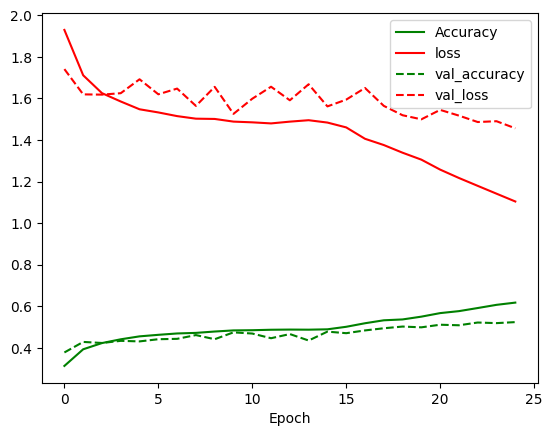

In [112]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.plot(accuracy, 'g-', label = 'Accuracy')
plt.plot(loss, 'r-', label = 'loss')
plt.plot(val_accuracy, 'g--', label = 'val_accuracy')
plt.plot(val_loss, 'r--', label = 'val_loss')
plt.xlabel('Epoch')
plt.legend(loc = 'best')
plt.show()